Grille chargée: 128x128
Température max: 86.51
Température min: 0.00
Température centre: 86.51


C:\Users\DELL\AppData\Local\Temp\ipykernel_28920\472055071.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


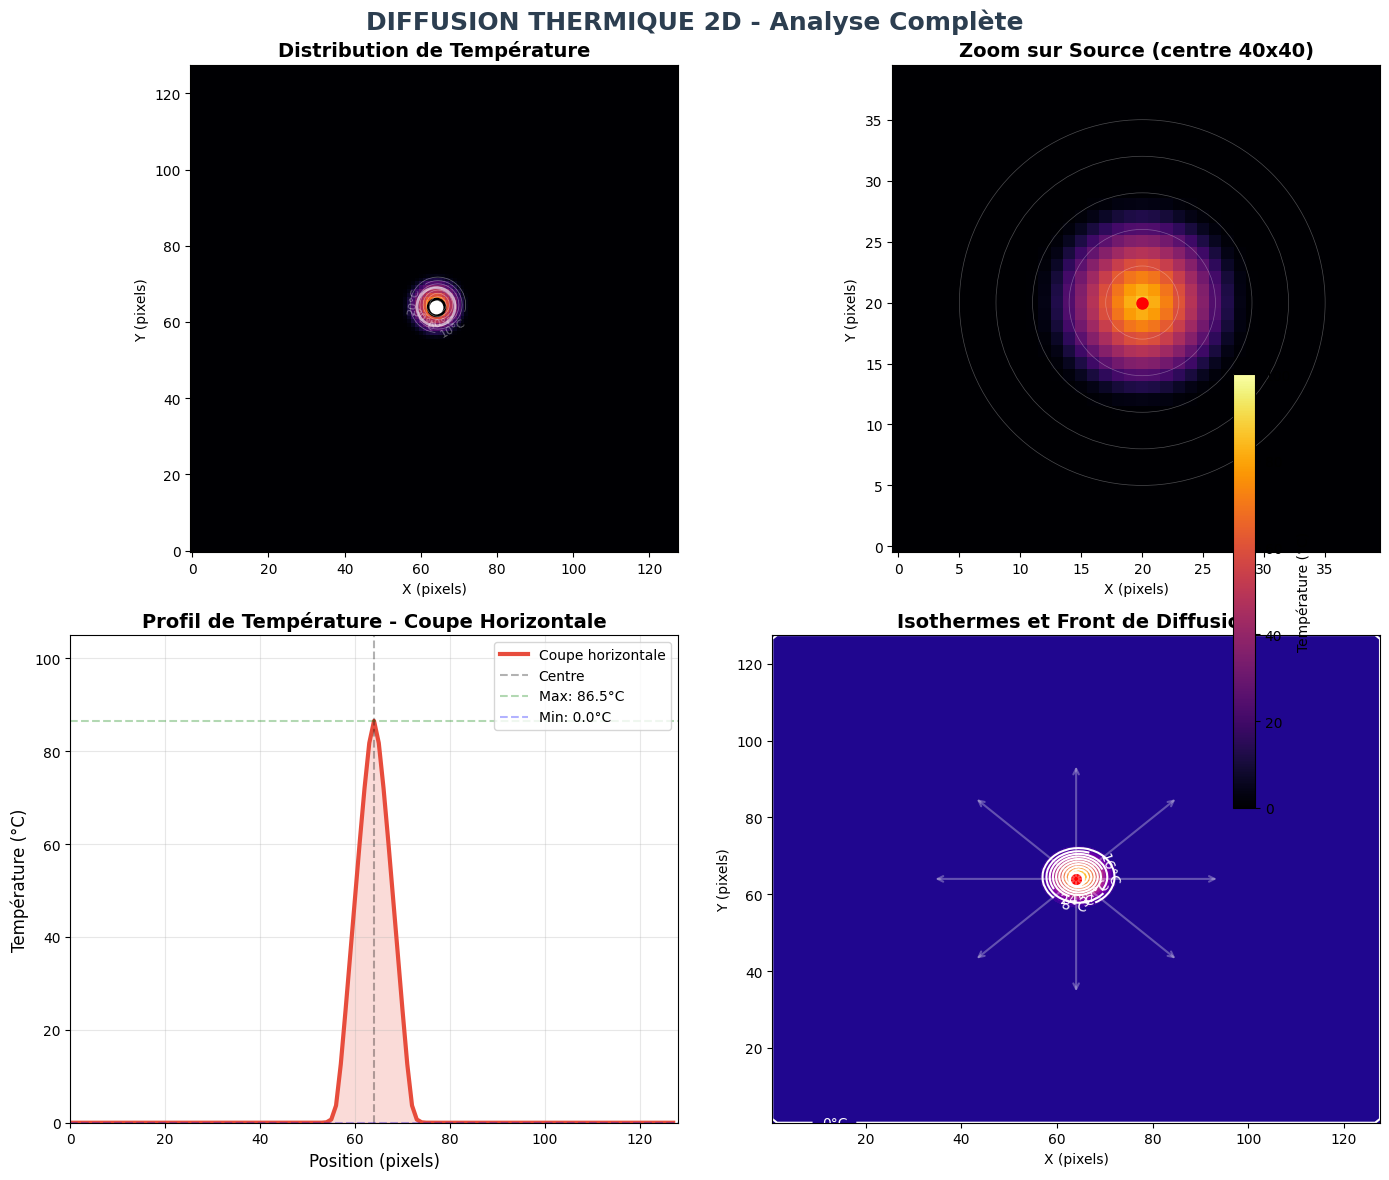


📊 STATISTIQUES:
  - Température max: 86.51°C
  - Température min: 0.00°C
  - Température moyenne: 0.41°C
  - Écart-type: 4.34°C
  - Zone chaude (>50°C): 45 cellules (0.3%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import pandas as pd

# === CHARGER CSV ===
data = pd.read_csv('temperature.csv', header=None)
grid = data.values
N = grid.shape[0]

print(f"Grille chargée: {N}x{N}")
print(f"Température max: {grid.max():.2f}")
print(f"Température min: {grid.min():.2f}")
print(f"Température centre: {grid[N//2, N//2]:.2f}")

# === VISUALISATION PRO ===
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('DIFFUSION THERMIQUE 2D - Analyse Complète', 
             fontsize=18, fontweight='bold', color='#2C3E50')

# === 1. HEATMAP PRINCIPALE ===
ax1 = axes[0, 0]
im1 = ax1.imshow(grid, cmap='inferno', origin='lower', vmin=0, vmax=100)
ax1.set_title('Distribution de Température', fontsize=14, fontweight='bold')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')

# Marquer la source
center = N // 2
ax1.plot(center, center, 'o', color='white', markersize=12, 
         markeredgecolor='black', markeredgewidth=2, label='Source')
ax1.add_patch(Circle((center, center), 5, color='white', fill=False, 
                      linewidth=2, alpha=0.6))

# Isothermes
levels = [10, 20, 30, 40, 50, 60, 70, 80, 90]
contour = ax1.contour(grid, levels=levels, colors='white', 
                      linewidths=0.5, alpha=0.4, origin='lower')
ax1.clabel(contour, inline=True, fontsize=8, fmt='%d°C')

# === 2. ZOOM SUR SOURCE ===
ax2 = axes[0, 1]
zoom = 20
zoom_grid = grid[center-zoom:center+zoom, center-zoom:center+zoom]
im2 = ax2.imshow(zoom_grid, cmap='inferno', origin='lower', vmin=0, vmax=100)
ax2.set_title(f'Zoom sur Source (centre {zoom*2}x{zoom*2})', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Y (pixels)')

# Ajouter des anneaux de diffusion
zoom_center = zoom
for r in [3, 6, 9, 12, 15]:
    ax2.add_patch(Circle((zoom_center, zoom_center), r, color='white', 
                         fill=False, linewidth=0.5, alpha=0.3))
ax2.plot(zoom_center, zoom_center, 'o', color='red', markersize=8)

# === 3. PROFIL DE TEMPÉRATURE ===
ax3 = axes[1, 0]
profile = grid[center, :]
x_axis = np.arange(N)

ax3.plot(x_axis, profile, linewidth=3, color='#E74C3C', label='Coupe horizontale')
ax3.axvline(x=center, color='black', linestyle='--', alpha=0.3, label='Centre')
ax3.axhline(y=grid.max(), color='green', linestyle='--', alpha=0.3, label=f'Max: {grid.max():.1f}°C')
ax3.axhline(y=grid.min(), color='blue', linestyle='--', alpha=0.3, label=f'Min: {grid.min():.1f}°C')

# Ajouter gradient
ax3.fill_between(x_axis, 0, profile, alpha=0.2, color='#E74C3C')

ax3.set_xlabel('Position (pixels)', fontsize=12)
ax3.set_ylabel('Température (°C)', fontsize=12)
ax3.set_title('Profil de Température - Coupe Horizontale', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper right')
ax3.set_xlim(0, N)
ax3.set_ylim(0, 105)

# === 4. ISOTHERMES + GRADIENT ===
ax4 = axes[1, 1]
im4 = ax4.contourf(grid, levels=20, cmap='plasma', origin='lower')
contour4 = ax4.contour(grid, levels=10, colors='white', linewidths=1.5, origin='lower')
ax4.clabel(contour4, inline=True, fontsize=10, fmt='%d°C')
ax4.plot(center, center, 'o', color='red', markersize=10, 
         markeredgecolor='white', markeredgewidth=2)

# Ajouter flèches de diffusion
arrow_style = dict(arrowstyle='->', color='white', lw=2, alpha=0.3)
for angle in [0, 45, 90, 135, 180, 225, 270, 315]:
    import math
    rad = math.radians(angle)
    x = center + 30 * math.cos(rad)
    y = center + 30 * math.sin(rad)
    ax4.annotate('', xy=(x, y), xytext=(center, center),
                 arrowprops=dict(arrowstyle='->', color='white', 
                                 lw=1.5, alpha=0.3))

ax4.set_title('Isothermes et Front de Diffusion', fontsize=14, fontweight='bold')
ax4.set_xlabel('X (pixels)')
ax4.set_ylabel('Y (pixels)')

# === COLORBAR ===
plt.colorbar(im1, ax=[ax1, ax2, ax4], orientation='vertical', 
             fraction=0.02, pad=0.02, label='Température (°C)')

# === AJUSTEMENT ===
plt.tight_layout()
plt.savefig('diffusion_thermique_pro.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# === STATISTIQUES ===
print("\n📊 STATISTIQUES:")
print(f"  - Température max: {grid.max():.2f}°C")
print(f"  - Température min: {grid.min():.2f}°C")
print(f"  - Température moyenne: {grid.mean():.2f}°C")
print(f"  - Écart-type: {grid.std():.2f}°C")
print(f"  - Zone chaude (>50°C): {(grid > 50).sum()} cellules ({(grid > 50).sum()/grid.size*100:.1f}%)")